# 01 — Dataset Audit & Exploration

## Driver Drowsiness Detection 

The goal is to understand the available data, verify image quality, identify duplicates, inspect class balance and image dimensions, and determine whether the dataset is suitable for separate:

- Eye-state classification: `Open` vs `Closed`
- Mouth-state classification: `no_yawn` vs `yawn`




In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "dataset" / "train"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())


Project root: D:\driver-drowsiness-detection
Dataset path: D:\driver-drowsiness-detection\dataset\train
Dataset exists: True


## 1. Discover Dataset Structure


In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}\n"
        "Make sure the dataset is extracted under dataset/train/."
    )

class_dirs = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])

print("Classes found:")
for folder in class_dirs:
    print(f"  - {folder.name}")

print("\nNumber of classes:", len(class_dirs))


Classes found:
  - Closed
  - no_yawn
  - Open
  - yawn

Number of classes: 4


In [3]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_dir in class_dirs:
    for image_path in sorted(class_dir.rglob("*")):
        if image_path.is_file() and image_path.suffix.lower() in SUPPORTED_EXTENSIONS:
            records.append({
                "path": str(image_path),
                "filename": image_path.name,
                "class": class_dir.name,
                "extension": image_path.suffix.lower()
            })

df = pd.DataFrame(records)

print(f"Total images found: {len(df):,}")
display(df.head())


Total images found: 2,900


,path,filename,class,extension
0,D:\driver-drowsiness-detection\dataset\train\C...,_0.jpg,Closed,.jpg
1,D:\driver-drowsiness-detection\dataset\train\C...,_1.jpg,Closed,.jpg
2,D:\driver-drowsiness-detection\dataset\train\C...,_10.jpg,Closed,.jpg
3,D:\driver-drowsiness-detection\dataset\train\C...,_100.jpg,Closed,.jpg
4,D:\driver-drowsiness-detection\dataset\train\C...,_101.jpg,Closed,.jpg


## 2. Class Distribution

,image_count
class,
Closed,726
Open,726
no_yawn,725
yawn,723


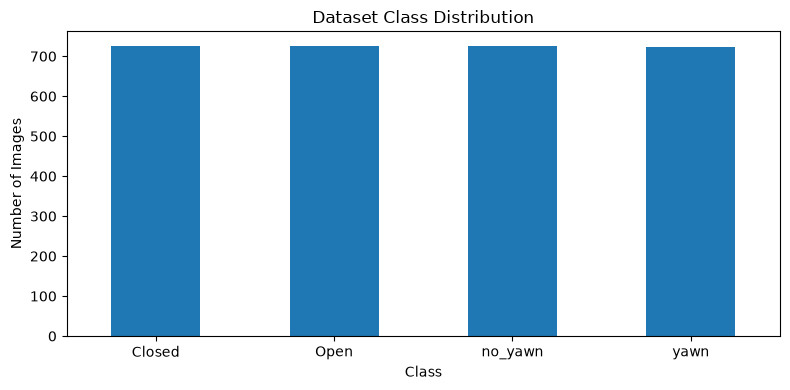

Minimum class size: 723
Maximum class size: 726
Class imbalance ratio: 1.004


In [4]:
class_counts = df["class"].value_counts().sort_index()

display(class_counts.rename("image_count").to_frame())

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Minimum class size:", class_counts.min())
print("Maximum class size:", class_counts.max())
print("Class imbalance ratio:", round(class_counts.max() / class_counts.min(), 3))


## 3. Image Metadata and Dimensions

- Width and height
- Number of channels
- File size
- Aspect ratio
- Image mode




In [7]:
metadata = []
corrupt_files = []

for row in df.to_dict("records"):
    path = Path(row["path"])

    try:
        # Verify that the image can be opened and read
        with Image.open(path) as img:
            img.verify()

        # Reopen after verify() and collect metadata
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
            channels = len(img.getbands())

        metadata.append({
            "path": row["path"],
            "filename": row["filename"],
            "class": row["class"],
            "width": width,
            "height": height,
            "channels": channels,
            "mode": mode,
            "aspect_ratio": round(width / height, 4),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
            "valid": True
        })

    except Exception as exc:
        corrupt_files.append({
            "path": row["path"],
            "class": row["class"],
            "error": str(exc)
        })

meta_df = pd.DataFrame(metadata)

print("Valid images:", len(meta_df))
print("Corrupt/unreadable images:", len(corrupt_files))

if corrupt_files:
    display(pd.DataFrame(corrupt_files).head(20))

display(meta_df.head())

Valid images: 2900
Corrupt/unreadable images: 0


,path,filename,class,width,height,channels,mode,aspect_ratio,file_size_kb,valid
0,D:\driver-drowsiness-detection\dataset\train\C...,_0.jpg,Closed,145,145,3,RGB,1.0000,6.09,True
1,D:\driver-drowsiness-detection\dataset\train\C...,_1.jpg,Closed,142,135,3,RGB,1.0519,10.14,True
2,D:\driver-drowsiness-detection\dataset\train\C...,_10.jpg,Closed,131,127,3,RGB,1.0315,25.28,True
3,D:\driver-drowsiness-detection\dataset\train\C...,_100.jpg,Closed,288,287,3,RGB,1.0035,17.08,True
4,D:\driver-drowsiness-detection\dataset\train\C...,_101.jpg,Closed,141,123,3,RGB,1.1463,26.18,True


In [8]:
dimension_summary = (
    meta_df.groupby("class")
    .agg(
        image_count=("path", "count"),
        unique_dimensions=("width", lambda x: x.nunique()),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
        mean_aspect_ratio=("aspect_ratio", "mean")
    )
    .round(3)
)

display(dimension_summary)


,image_count,unique_dimensions,min_width,max_width,min_height,max_height,mean_aspect_ratio
class,,,,,,,
Closed,726,397,67,1625,54,1625,1.089
Open,726,385,50,1514,40,1515,1.132
no_yawn,725,1,640,640,480,480,1.333
yawn,723,1,640,640,480,480,1.333


## 4. Common Dimensions by Class



In [9]:
common_dimensions = (
    meta_df.groupby(["class", "width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values(["class", "count"], ascending=[True, False])
)

for class_name in sorted(meta_df["class"].unique()):
    print(f"\n{class_name}")
    display(common_dimensions[common_dimensions["class"] == class_name].head(10))



Closed


,class,width,height,count
345,Closed,323,300,6
366,Closed,342,300,6
285,Closed,300,300,5
409,Closed,381,300,5
584,Closed,1280,1280,5
291,Closed,300,306,4
304,Closed,300,322,4
321,Closed,304,300,4
344,Closed,322,300,4
350,Closed,329,300,4



Open


,class,width,height,count
851,Open,300,300,9
950,Open,370,300,5
896,Open,316,300,4
973,Open,395,300,4
976,Open,398,300,4
979,Open,400,300,4
670,Open,116,116,3
687,Open,126,126,3
694,Open,130,130,3
858,Open,300,309,3



no_yawn


,class,width,height,count
1167,no_yawn,640,480,725



yawn


,class,width,height,count
1168,yawn,640,480,723


## 5. Exact Duplicate Detection



In [10]:
def file_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

meta_df["file_md5"] = meta_df["path"].map(file_md5)

duplicate_groups = (
    meta_df.groupby("file_md5")
    .filter(lambda g: len(g) > 1)
    .sort_values("file_md5")
)

duplicate_count = duplicate_groups["file_md5"].nunique()

print("Exact duplicate groups:", duplicate_count)
print("Images involved in exact duplicates:", len(duplicate_groups))

if not duplicate_groups.empty:
    display(duplicate_groups[["class", "filename", "path", "file_md5"]].head(30))
else:
    print("No exact duplicate images found.")


Exact duplicate groups: 0
Images involved in exact duplicates: 0
No exact duplicate images found.


## 6. Near-Duplicate Screening

Exact duplicates are not enough. Similar images can also create leakage.



In [11]:
def average_hash(path, hash_size=16):
    with Image.open(path) as img:
        img = img.convert("L").resize((hash_size, hash_size))
        arr = np.asarray(img, dtype=np.float32)
    return arr > arr.mean()

def hamming_distance(hash_a, hash_b):
    return int(np.count_nonzero(hash_a != hash_b))

# Compute hashes for all valid images.
hashes = {}
for path in meta_df["path"]:
    try:
        hashes[path] = average_hash(path)
    except Exception:
        pass

# Screen only very similar images within the same broad class.
near_duplicate_pairs = []
paths = list(hashes.keys())

# 2,900 images is small enough for this lightweight screening.
for i in range(len(paths)):
    for j in range(i + 1, len(paths)):
        d = hamming_distance(hashes[paths[i]], hashes[paths[j]])
        if d <= 2:
            class_i = meta_df.loc[meta_df["path"] == paths[i], "class"].iloc[0]
            class_j = meta_df.loc[meta_df["path"] == paths[j], "class"].iloc[0]
            near_duplicate_pairs.append((paths[i], paths[j], d, class_i, class_j))

print("Potential near-duplicate pairs (hash distance <= 2):", len(near_duplicate_pairs))

if near_duplicate_pairs:
    near_df = pd.DataFrame(
        near_duplicate_pairs,
        columns=["path_a", "path_b", "hash_distance", "class_a", "class_b"]
    )
    display(near_df.head(20))
else:
    print("No highly similar pairs detected by this screening threshold.")


Potential near-duplicate pairs (hash distance <= 2): 702


,path_a,path_b,hash_distance,class_a,class_b
0,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,1,no_yawn,no_yawn
1,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
2,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
3,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,1,no_yawn,no_yawn
4,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
5,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
6,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
7,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,no_yawn
8,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,1,no_yawn,no_yawn
9,D:\driver-drowsiness-detection\dataset\train\n...,D:\driver-drowsiness-detection\dataset\train\n...,1,no_yawn,no_yawn


## 7. Visual Inspection of Representative Images




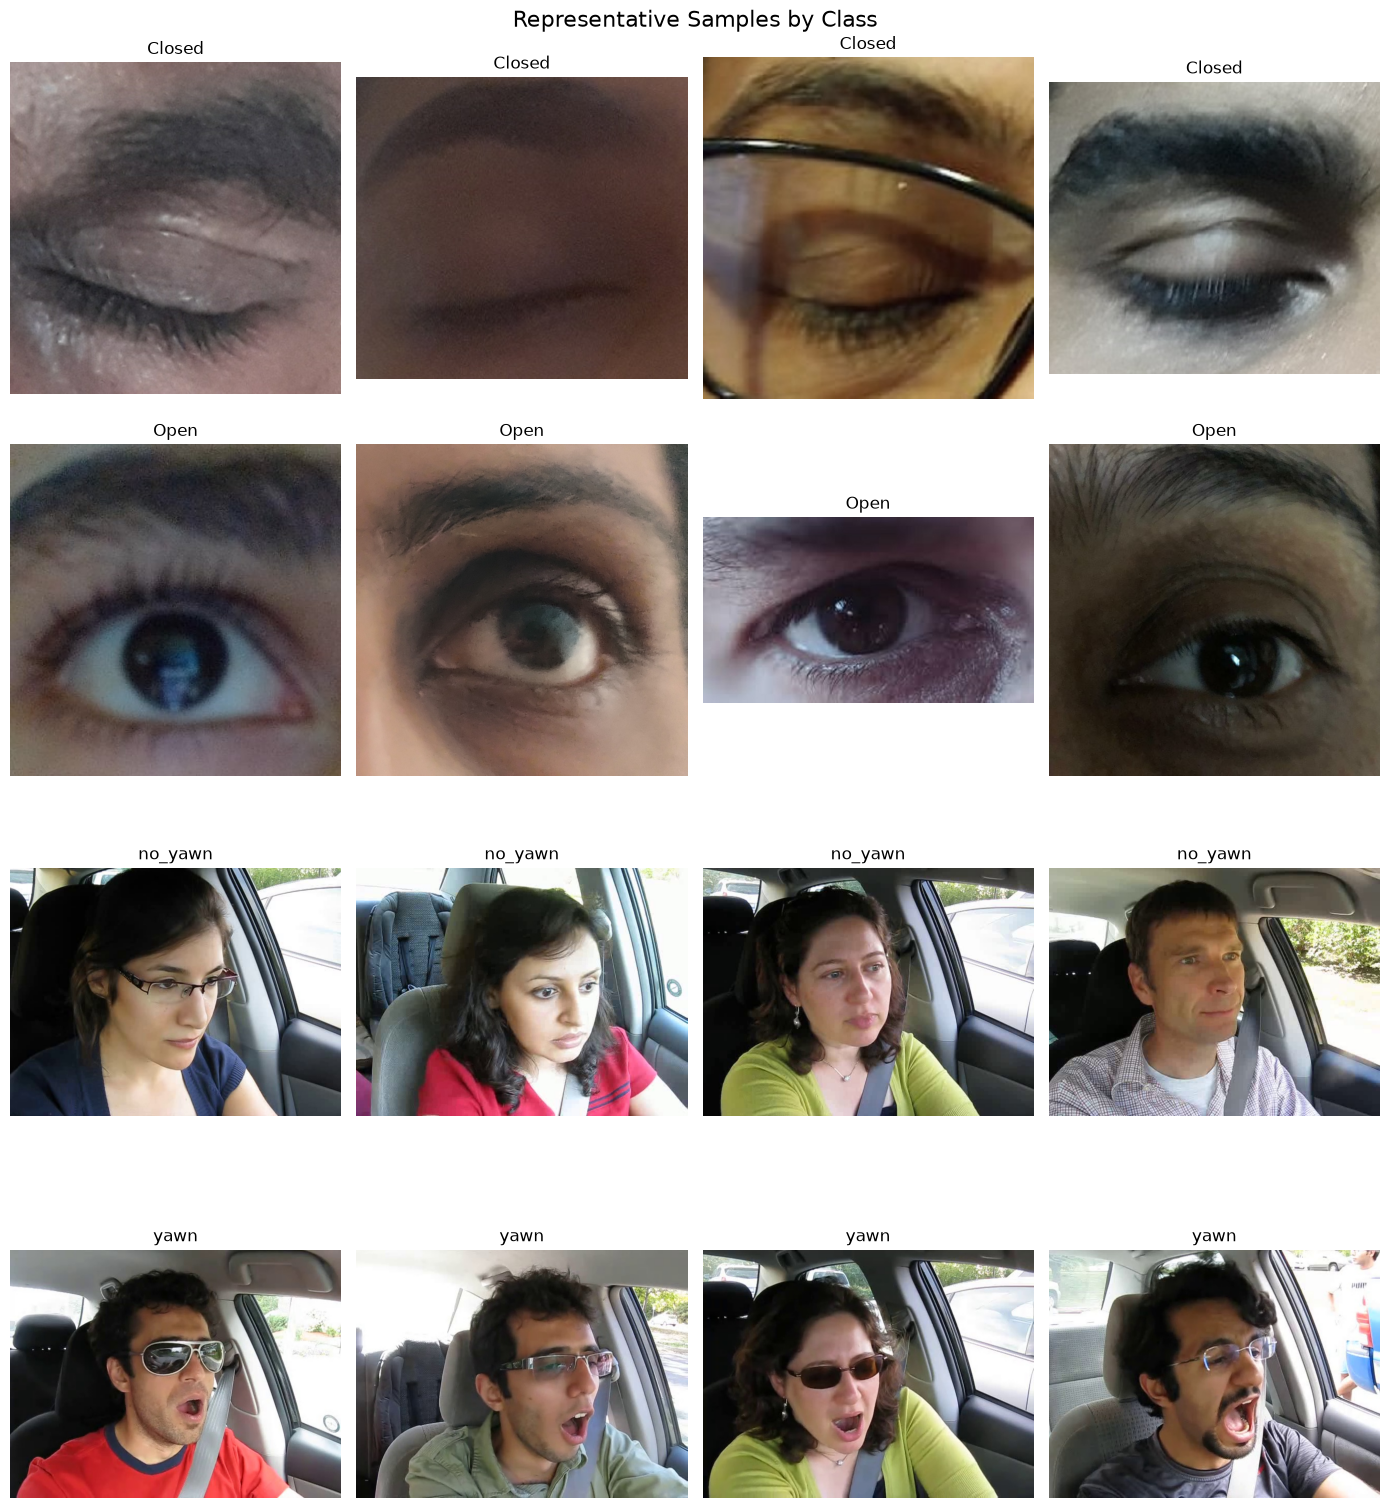

In [12]:
rng = np.random.default_rng(42)

classes = sorted(meta_df["class"].unique())

fig, axes = plt.subplots(len(classes), 4, figsize=(14, 4 * len(classes)))

for row_idx, class_name in enumerate(classes):
    class_paths = meta_df.loc[meta_df["class"] == class_name, "path"].tolist()
    selected = rng.choice(class_paths, size=min(4, len(class_paths)), replace=False)

    for col_idx, path in enumerate(selected):
        with Image.open(path) as img:
            axes[row_idx, col_idx].imshow(img.convert("RGB"))

        axes[row_idx, col_idx].set_title(class_name)
        axes[row_idx, col_idx].axis("off")

    for col_idx in range(len(selected), 4):
        axes[row_idx, col_idx].axis("off")

plt.suptitle("Representative Samples by Class", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
# Save audit metadata for later notebooks.
meta_output = OUTPUT_DIR / "dataset_image_metadata.csv"
meta_df.to_csv(meta_output, index=False)

summary_output = OUTPUT_DIR / "dataset_class_summary.csv"
class_counts.rename("image_count").to_csv(summary_output, header=True)

print("Saved:")
print(" ", meta_output)
print(" ", summary_output)


Saved:
  D:\driver-drowsiness-detection\outputs\dataset_image_metadata.csv
  D:\driver-drowsiness-detection\outputs\dataset_class_summary.csv
